# Verifying Isolation Properties with Whirlpool

The `pybatfish` question is in development, so these inputs are currently just strings. For this reason, in this notebook and in the file `whirlpool.py` I've included functions and classes to abstract some of the strings so that it is easier to use. The examples below make use of these classes and functions.


## API Usage within Notebook
The code below provides some support and abstraction for querying to the `pybatfish.whirlpoolIsolation` question. The main advantage of using the code below is that you don't have to worry about formatting the strings correctly to get passed into the direct `pybatfish` query. In the future, we hope to add to the pybatfish library so usage is less hacky/more seamless.

In [1]:
%run ../api/startup.py

In [2]:
import sys,os
sys.path.insert(0, '../api')
import whirlpool, startup

In [3]:
# A LocationPropertyPair consists of a location and a property which is represented as a DNF (disjunction of clauses) 
target_example = whirlpool.LocationPropertyPair(location="node1",property=[whirlpool.Clause(prefixes=["!25.13.0.0/16"])])

# These are two assumptions at edges which come from external ips - the first is conjunction, second is disjunction
# A Clause takes two possible fields (communities and prefixes) which are interpreted as being conjoined, default if not provide is empty list
assumption_example_one = whirlpool.LocationPropertyPair(location="100.0.0.1 -> bordera",property=[whirlpool.Clause(communities=["10:10","!20:20"],prefixes=["10.20.0.0/16"])])
assumption_example_two = whirlpool.LocationPropertyPair(location="100.0.0.2 -> borderb",property=[whirlpool.Clause(prefixes=["!100.0.0.0/8"]),whirlpool.Clause(communities=["1:1"])])

query_with_no_assumptions = whirlpool.IsolationQuery(target=target_example)
query_with_assumptions = whirlpool.IsolationQuery(target=target_example,assumptions=[assumption_example_one,assumption_example_two])

# You can also provide a default assumption. If you don't want to have the blanket assumption be that any incoming traffic is possible, 
# you can provide an assumption that will hold on any incoming traffic.

# The query below assumes that incoming traffic has the community 1:1 or prefix 10.20.0.0/16, besides the explicit provided assumption assumption_example_one
default = whirlpool.Property([whirlpool.Clause(prefixes=["10.20.0.0/16"]),whirlpool.Clause(communities=["1:1"])])
query_with_default = query_with_no_assumptions = whirlpool.IsolationQuery(target=target_example,assumptions=[assumption_example_one],default=default)

## Example One
This example is a simple three-node network which is shown below. The property that we want to verify is that no traffic going from the `Border3` node (ip address of `10.0.0.3`) to the outside of the network (to `100.0.0.2`) has the prefix `25.13.0.0/16`. The goal is to do this by using the community `10:10` to tag this traffic coming from the node `100.0.0.1`. 

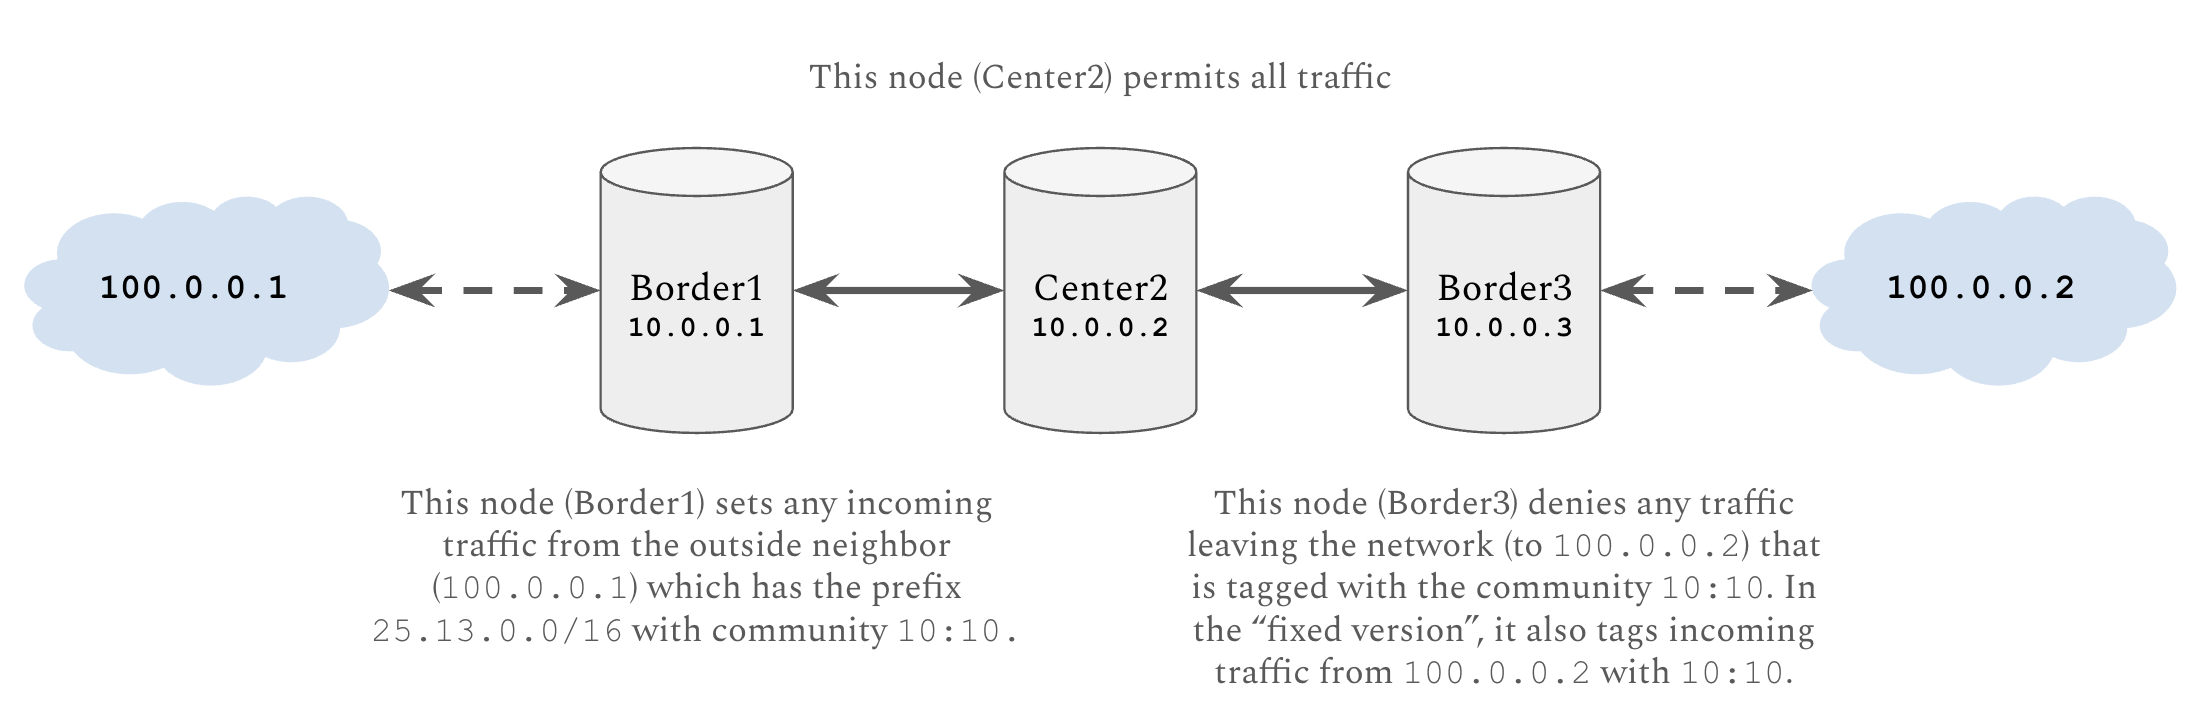

In [4]:
networkName = "exampleOne_network"
snapshotName = "exampleOne_snapshot"
snapshotPath = "isolation_snapshots/exampleOne"

target = whirlpool.LocationPropertyPair(location="border3 -> 100.0.0.2",property=[whirlpool.Clause(prefixes=["!25.13.0.0/16"])])
assumption = whirlpool.LocationPropertyPair(location="100.0.0.1 -> border1",property=[whirlpool.Clause(prefixes=["!25.13.0.0/16"])])
default = whirlpool.Property([whirlpool.Clause(communities=["!10:10"])])

query = whirlpool.IsolationQuery(target=target,assumptions=[assumption],default=default)

df = startup.runWhirlpoolQuery(networkName,snapshotName,snapshotPath,query,display=True)

,Location_Relevance,Provided_Invariant,Network_Locations,Inferred_Invariant,Counterexample
0,Target,!prefix([25.13.0.0/16]),(border3) 10.0.0.3 -> 100.0.0.2,!prefix([25.13.0.0/16]),
1,Assumption,!comm(10:10),100.0.0.2 -> 10.0.0.3 (border3),!prefix(25.13.0.0/16) OR comm(10:10),Bgpv4Route{network=25.13.0.0/16}
2,Assumption,!prefix([25.13.0.0/16]),100.0.0.1 -> 10.0.0.1 (border1),true,
3,Internal Location,,"(border3) 10.0.0.3 -> 10.0.0.2 (center2), center2 (10.0.0.2), (center2) 10.0.0.2 -> 10.0.0.3 (border3), (center2) 10.0.0.2 -> 10.0.0.1 (border1), border1 (10.0.0.1), border3 (10.0.0.3), (border1) 10.0.0.1 -> 10.0.0.2 (center2)",!prefix(25.13.0.0/16) OR comm(10:10),


The previous examples failed overall verification because even though the input edge from the ip address `100.0.0.1` infers the invariant true (implying an incoming traffic is ok), on the other end, we need to make sure that the prefix we are trying to avoid (`25.13.0.0/16`) doesn't come from the other outside incoming edge (`100.0.0.2 -> 10.0.0.3`). 

This assumption makes sense if we want to prove that routes with this prefix don't come out to the node `100.0.0.2`, then we would assume it wouldn't send those routes back into the network. This is updated in the following section by adding that any traffic coming in on the edge `10.0.0.3` from `100.0.0.2` does not have the prefix `25.13.0.0/16`. Alternatively, we can state that this traffic should be assumed to have a conflicting prefix (this is commented out).

In [5]:
networkName = "exampleOne_network"
snapshotName = "exampleOne_snapshot"
snapshotPath = "isolation_snapshots/exampleOne"

target = whirlpool.LocationPropertyPair(location="border3 -> 100.0.0.2",property=[whirlpool.Clause(prefixes=["!25.13.0.0/16"])])
assumption = whirlpool.LocationPropertyPair(location="100.0.0.2 -> border3",property=[whirlpool.Clause(prefixes=["!25.13.0.0/16"])])

query = whirlpool.IsolationQuery(target=target,assumptions=[assumption])

df = startup.runWhirlpoolQuery(networkName,snapshotName,snapshotPath,query,display=True)

,Location_Relevance,Provided_Invariant,Network_Locations,Inferred_Invariant,Counterexample
0,Target,!prefix([25.13.0.0/16]),(border3) 10.0.0.3 -> 100.0.0.2,!prefix([25.13.0.0/16]),
1,Assumption,!prefix([25.13.0.0/16]),100.0.0.2 -> 10.0.0.3 (border3),!prefix(25.13.0.0/16) OR comm(10:10),
2,Assumption,true,100.0.0.1 -> 10.0.0.1 (border1),true,
3,Internal Location,,"(border3) 10.0.0.3 -> 10.0.0.2 (center2), center2 (10.0.0.2), (center2) 10.0.0.2 -> 10.0.0.3 (border3), (center2) 10.0.0.2 -> 10.0.0.1 (border1), border1 (10.0.0.1), border3 (10.0.0.3), (border1) 10.0.0.1 -> 10.0.0.2 (center2)",!prefix(25.13.0.0/16) OR comm(10:10),


Another way to fix this network is to say that any incoming traffic (to the node `10.0.0.3`) from the outside nodes (in this example that is `100.0.0.2`) is also tagged with the community. This would ensure that the traffic is not sent back to the outside node it was received from. This is shown in the example below. This is likely a better fix than the previous one because it makes no assumptions about traffic coming into the network.

In [6]:
networkName = "exampleOne_fixed_network"
snapshotName = "exampleOne_fixed_snapshot"
snapshotPath = "isolation_snapshots/exampleOneFixed"

target = whirlpool.LocationPropertyPair(location="border3 -> 100.0.0.2",property=[whirlpool.Clause(prefixes=["!25.13.0.0/16"])])
query = whirlpool.IsolationQuery(target=target)

df = startup.runWhirlpoolQuery(networkName,snapshotName,snapshotPath,query,display=True)

,Location_Relevance,Provided_Invariant,Network_Locations,Inferred_Invariant,Counterexample
0,Target,!prefix([25.13.0.0/16]),(border3) 10.0.0.3 -> 100.0.0.2,!prefix([25.13.0.0/16]),
1,Assumption,true,"100.0.0.2 -> 10.0.0.3 (border3), 100.0.0.1 -> 10.0.0.1 (border1)",true,
2,Internal Location,,"(border3) 10.0.0.3 -> 10.0.0.2 (center2), center2 (10.0.0.2), (center2) 10.0.0.2 -> 10.0.0.3 (border3), (center2) 10.0.0.2 -> 10.0.0.1 (border1), border1 (10.0.0.1), border3 (10.0.0.3), (border1) 10.0.0.1 -> 10.0.0.2 (center2)",!prefix(25.13.0.0/16) OR comm(10:10),


## Example Two

This example is a network where the intent is only permit outgoing traffic to `100.0.0.4` which has passed through both nodes "border1" and "border2." This is implemented by tagging routes with communities `100:1` and `100:2` when passing through "border1" and "border2" respectively. And then checking that if these communities are tagged in the middle node, then the community `100:3` is added (which is then used as a filter at the final border node "border4"). [There is a typo in the image below, the final node should say that it only permits traffic which is tagged with the community `100:3`.]

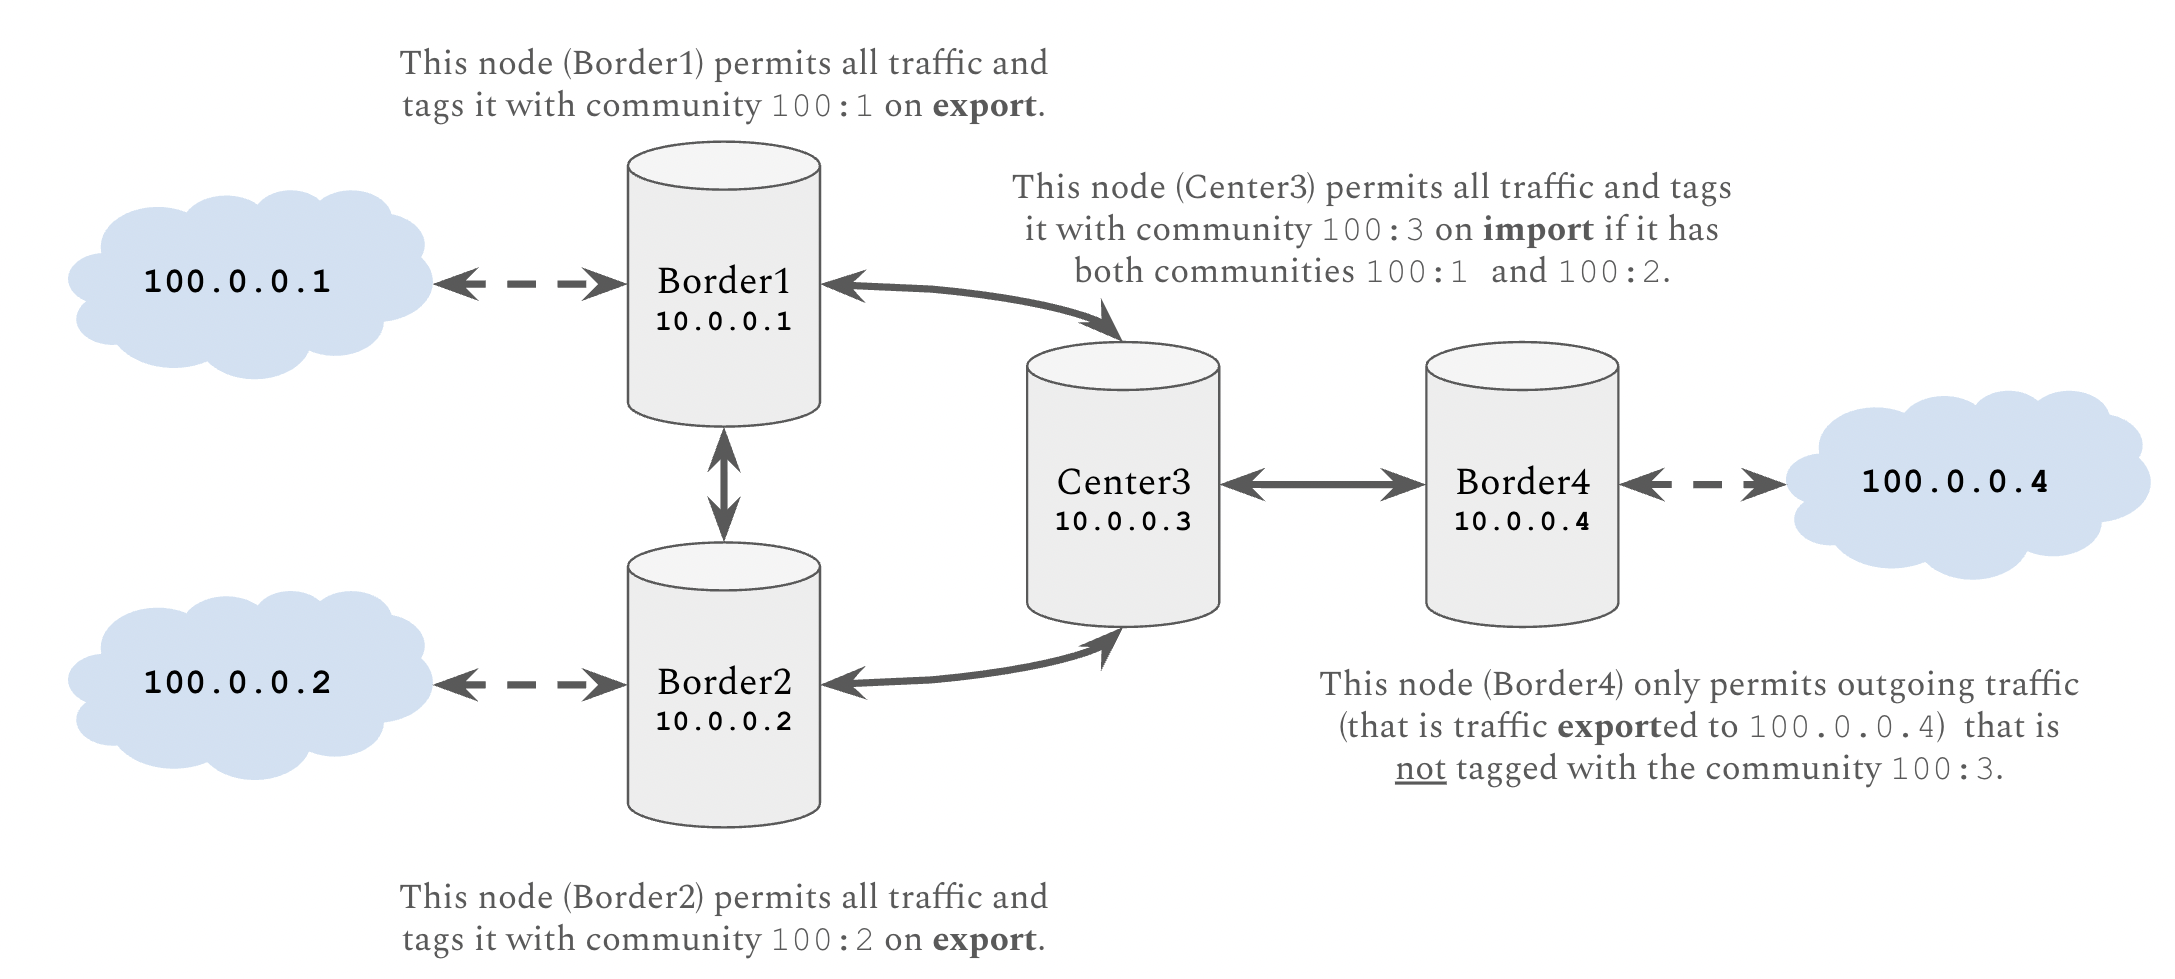

In [7]:
networkName = "exampleTwo_network"
snapshotName = "exampleTwo_snapshot"
snapshotPath = "isolation_snapshots/exampleTwo"

target = whirlpool.LocationPropertyPair(location="border4 -> 100.0.0.4",property=[whirlpool.Clause(communities=["100:1","100:2"])])

query = whirlpool.IsolationQuery(target=target)

df = startup.runWhirlpoolQuery(networkName,snapshotName,snapshotPath,query,display=True)

,Location_Relevance,Provided_Invariant,Network_Locations,Inferred_Invariant,Counterexample
0,Target,"comm(100:1),comm(100:2)",(border4) 10.0.0.4 -> 100.0.0.4,"comm(100:1),comm(100:2)",
1,Assumption,true,100.0.0.4 -> 10.0.0.4 (border4),"!comm(100:2),!comm(100:3) OR !comm(100:3),comm(100:2) OR comm(100:1),comm(100:2),comm(100:3)","Bgpv4Route{network=10.0.0.0/8, communities=CommunitySet{communities=[100:3]}}"
2,Assumption,true,"100.0.0.2 -> 10.0.0.2 (border2), 100.0.0.1 -> 10.0.0.1 (border1)",!comm(100:3) OR comm(100:2),"Bgpv4Route{network=10.0.0.0/8, communities=CommunitySet{communities=[100:3]}}"
3,Internal Location,,"(border4) 10.0.0.4 -> 10.0.0.3 (center3), border4 (10.0.0.4), center3 (10.0.0.3), (center3) 10.0.0.3 -> 10.0.0.4 (border4), (border1) 10.0.0.1 -> 10.0.0.3 (center3), (border2) 10.0.0.2 -> 10.0.0.3 (center3)","!comm(100:2),!comm(100:3) OR !comm(100:3),comm(100:2) OR comm(100:1),comm(100:2),comm(100:3)",
4,Internal Location,,"(center3) 10.0.0.3 -> 10.0.0.2 (border2), (border2) 10.0.0.2 -> 10.0.0.1 (border1), (border1) 10.0.0.1 -> 10.0.0.2 (border2), (center3) 10.0.0.3 -> 10.0.0.1 (border1), border2 (10.0.0.2), border1 (10.0.0.1)",!comm(100:3) OR comm(100:2),


This previous example fails because at the center node, initially we checked if the route had both communities`100:1` and `100:2` and flagged with `100:3` if so, else we permitted without modification. However, the subtle distinction is that the  routes coming out of this node should have the community `100:3` _if and only if_ it has both the communities `100:1` and `100:2`. The code below runs the example `exampleTwoBetter` which fixes this by stripping comunities at the center node (`10.0.0.3`) if the route does not have both `100:1` and `100:2` and has `100:3`.

In [8]:
networkName = "exampleTwo_better_network"
snapshotName = "exampleTwo_better_snapshot"
snapshotPath = "isolation_snapshots/exampleTwoBetter"

target = whirlpool.LocationPropertyPair(location="border4 -> 100.0.0.4",property=[whirlpool.Clause(communities=["100:1","100:2"])])

query = whirlpool.IsolationQuery(target=target)

df = startup.runWhirlpoolQuery(networkName,snapshotName,snapshotPath,query,display=True)

,Location_Relevance,Provided_Invariant,Network_Locations,Inferred_Invariant,Counterexample
0,Target,"comm(100:1),comm(100:2)",(border4) 10.0.0.4 -> 100.0.0.4,"comm(100:1),comm(100:2)",
1,Assumption,true,100.0.0.4 -> 10.0.0.4 (border4),"!comm(100:2),!comm(100:3) OR !comm(100:3),comm(100:2) OR comm(100:1),comm(100:2),comm(100:3)","Bgpv4Route{network=10.0.0.0/8, communities=CommunitySet{communities=[100:3]}}"
2,Assumption,true,"100.0.0.2 -> 10.0.0.2 (border2), 100.0.0.1 -> 10.0.0.1 (border1)",true,
3,Internal Location,,"border4 (10.0.0.4), center3 (10.0.0.3), (center3) 10.0.0.3 -> 10.0.0.4 (border4)","!comm(100:2),!comm(100:3) OR !comm(100:3),comm(100:2) OR comm(100:1),comm(100:2),comm(100:3)",
4,Internal Location,,"(border4) 10.0.0.4 -> 10.0.0.3 (center3), (center3) 10.0.0.3 -> 10.0.0.2 (border2), (border2) 10.0.0.2 -> 10.0.0.1 (border1), (border1) 10.0.0.1 -> 10.0.0.2 (border2), (center3) 10.0.0.3 -> 10.0.0.1 (border1), border2 (10.0.0.2), (border1) 10.0.0.1 -> 10.0.0.3 (center3), border1 (10.0.0.1), (border2) 10.0.0.2 -> 10.0.0.3 (center3)",true,


Verifcation is again incomplete. This is because of a similar reason to the last example - that is, we are focusing on only advertising routes which have gone through both nodes "border1" and "border2" but we are not considering that there are input routes from the other side. To fix this without changing configs, we can assume that any routes coming into the network from the node `100.0.0.4` do not have the community `100:3`.

In [9]:
networkName = "exampleTwo_better_network"
snapshotName = "exampleTwo_better_snapshot"
snapshotPath = "isolation_snapshots/exampleTwoBetter"

target = whirlpool.LocationPropertyPair(location="border4 -> 100.0.0.4",property=[whirlpool.Clause(communities=["100:1","100:2"])])
assumption = whirlpool.LocationPropertyPair(location="100.0.0.4 -> border4",property=[whirlpool.Clause(communities=["!100:3"])])

query = whirlpool.IsolationQuery(target=target,assumptions=[assumption])

df = startup.runWhirlpoolQuery(networkName,snapshotName,snapshotPath,query,display=True)

,Location_Relevance,Provided_Invariant,Network_Locations,Inferred_Invariant,Counterexample
0,Target,"comm(100:1),comm(100:2)",(border4) 10.0.0.4 -> 100.0.0.4,"comm(100:1),comm(100:2)",
1,Assumption,!comm(100:3),100.0.0.4 -> 10.0.0.4 (border4),"!comm(100:2),!comm(100:3) OR !comm(100:3),comm(100:2) OR comm(100:1),comm(100:2),comm(100:3)",
2,Assumption,true,"100.0.0.2 -> 10.0.0.2 (border2), 100.0.0.1 -> 10.0.0.1 (border1)",true,
3,Internal Location,,"border4 (10.0.0.4), center3 (10.0.0.3), (center3) 10.0.0.3 -> 10.0.0.4 (border4)","!comm(100:2),!comm(100:3) OR !comm(100:3),comm(100:2) OR comm(100:1),comm(100:2),comm(100:3)",
4,Internal Location,,"(border4) 10.0.0.4 -> 10.0.0.3 (center3), (center3) 10.0.0.3 -> 10.0.0.2 (border2), (border2) 10.0.0.2 -> 10.0.0.1 (border1), (border1) 10.0.0.1 -> 10.0.0.2 (border2), (center3) 10.0.0.3 -> 10.0.0.1 (border1), border2 (10.0.0.2), (border1) 10.0.0.1 -> 10.0.0.3 (center3), border1 (10.0.0.1), (border2) 10.0.0.2 -> 10.0.0.3 (center3)",true,


Similar to before, there is a "better" fix which involes changing the configs. The change reflected in `exampleTwoFixed` (in addition to the first fix) also strips any communities coming from outside the network into the node "border4." And now our small network behaves as intended!

In [10]:
networkName = "exampleTwo_fixed_network"
snapshotName = "exampleTwo_fixed_snapshot"
snapshotPath = "isolation_snapshots/exampleTwoFixed"

target = whirlpool.LocationPropertyPair(location="border4 -> 100.0.0.4",property=[whirlpool.Clause(communities=["100:1","100:2"])])

query = whirlpool.IsolationQuery(target=target)

df = startup.runWhirlpoolQuery(networkName,snapshotName,snapshotPath,query,display=True)

,Location_Relevance,Provided_Invariant,Network_Locations,Inferred_Invariant,Counterexample
0,Target,"comm(100:1),comm(100:2)",(border4) 10.0.0.4 -> 100.0.0.4,"comm(100:1),comm(100:2)",
1,Assumption,true,"100.0.0.2 -> 10.0.0.2 (border2), 100.0.0.4 -> 10.0.0.4 (border4), 100.0.0.1 -> 10.0.0.1 (border1)",true,
2,Internal Location,,"(border4) 10.0.0.4 -> 10.0.0.3 (center3), (center3) 10.0.0.3 -> 10.0.0.2 (border2), (border2) 10.0.0.2 -> 10.0.0.1 (border1), (border1) 10.0.0.1 -> 10.0.0.2 (border2), (center3) 10.0.0.3 -> 10.0.0.1 (border1), border2 (10.0.0.2), (border1) 10.0.0.1 -> 10.0.0.3 (center3), border1 (10.0.0.1), (border2) 10.0.0.2 -> 10.0.0.3 (center3)",true,
3,Internal Location,,"border4 (10.0.0.4), center3 (10.0.0.3), (center3) 10.0.0.3 -> 10.0.0.4 (border4)","!comm(100:1),!comm(100:3) OR !comm(100:3),comm(100:1) OR comm(100:1),comm(100:2),comm(100:3)",


## Example Three

Example three is a layered network; each of the nodes is copy of the others in their layer just with differnt ip addresses. 

The first layer strips communities when they enter from the node; and for the export to the second, if the route has the prefix `25.13.17.0/24` it is tagged with the community `10:10`, then if has the prefix `25.13.0.0/16` and not `25.13.17.0/24` then it is tagged with community `20:20` otherwise it has no communities.

The second layer, on import, sets any route with the community `20:20` to have the community `30:30`. Otherwise, the route is tagged with the community `40:40`.

The third layer only has policies going towards the outside (`100.0.0.2` and `100.0.1.2`). Nothing is imported from the outside and any route with the community `40:40` is denied from being exported outside the network.

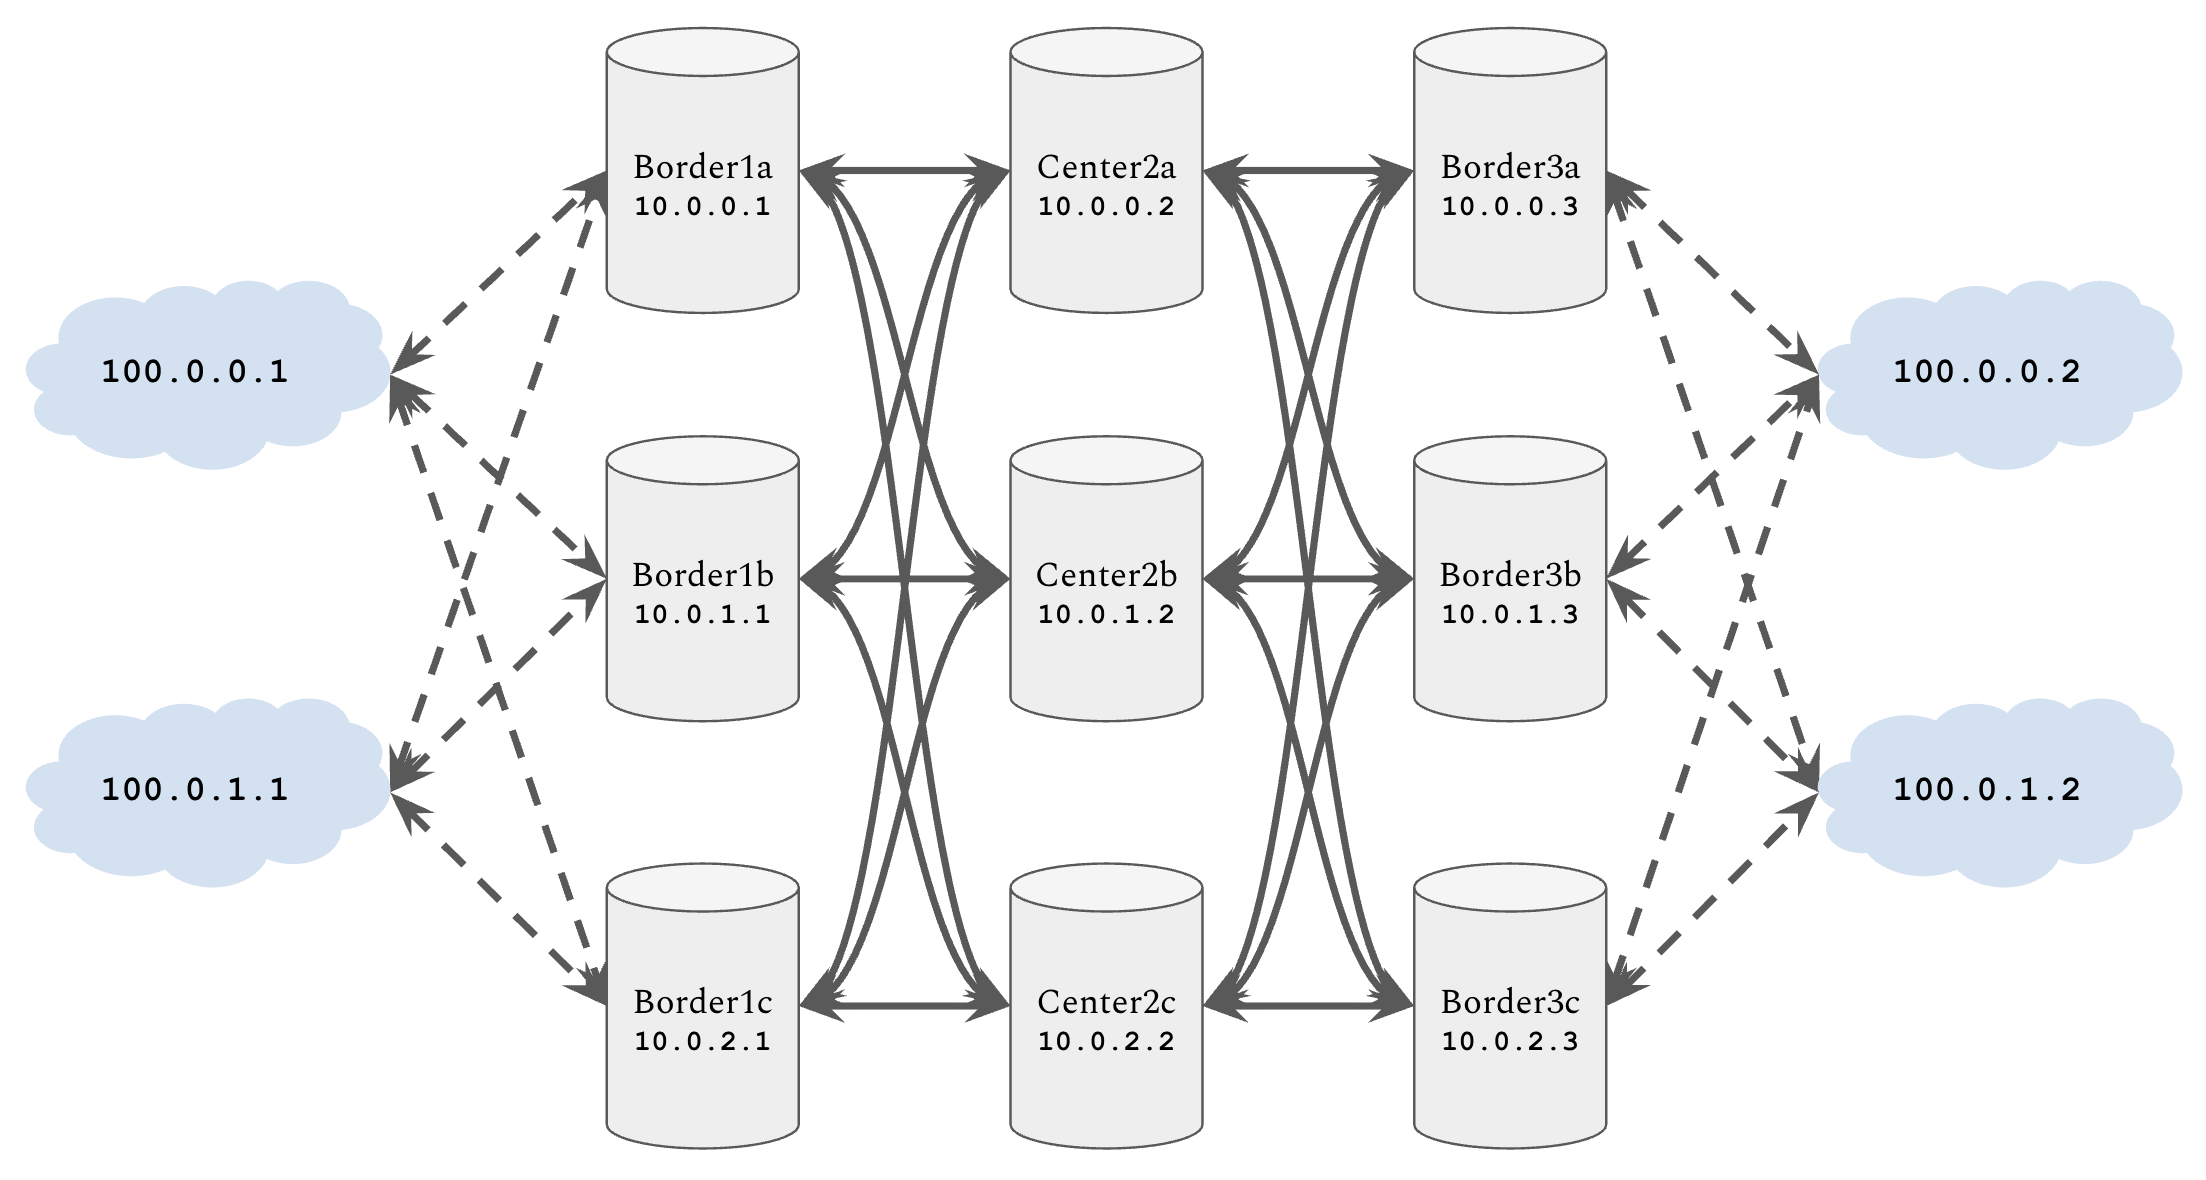

In this case there are six different outgoing edges from the third layer which we want to verify a property about (the same property). Currently, the `verify` question API does not support multiple target properties to verify - so you can run each individually to see they are all true. This feature will be added soon after initial testing.

_Note:_ This is the first example we'll show where the BDD for some invariant that we infer is too complicated for us to display. It isn't that the invariant itself is too long or complicated, but that translating the BDD to an understandable string is too inefficient. This current feature is a work in progress, and in the current version, we make a best effort attempt otherwise report the limitation (seen below as "LIMIT (Complex BDD)").

In [11]:
networkName = "exampleThree_network"
snapshotName = "exampleThree_snapshot"
snapshotPath = "isolation_snapshots/exampleThree"

target = whirlpool.LocationPropertyPair(location="border3a -> 100.0.0.2",property=[whirlpool.Clause(prefixes=["25.13.0.0/16:16-32","!25.13.17.0/24:24-32"])])

query = whirlpool.IsolationQuery(target=target)

df = startup.runWhirlpoolQuery(networkName,snapshotName,snapshotPath,query,display=True)

,Location_Relevance,Provided_Invariant,Network_Locations,Inferred_Invariant,Counterexample
0,Target,"!prefix([25.13.17.0/24:24-32]),prefix([25.13.0.0/16:16-32])",(border3a) 10.0.0.3 -> 100.0.0.2,"!prefix([25.13.17.0/24:24-32]),prefix([25.13.0.0/16:16-32])",
1,Assumption,true,"100.0.1.1 -> 10.0.2.1 (border1c), 100.0.1.1 -> 10.0.1.1 (border1b), 100.0.1.1 -> 10.0.0.1 (border1a), 100.0.0.1 -> 10.0.0.1 (border1a), 100.0.0.2 -> 10.0.1.3 (border3b), 100.0.0.2 -> 10.0.0.3 (border3a), 100.0.1.2 -> 10.0.2.3 (border3c), 100.0.0.1 -> 10.0.2.1 (border1c), 100.0.0.1 -> 10.0.1.1 (border1b), 100.0.1.2 -> 10.0.1.3 (border3b), 100.0.1.2 -> 10.0.0.3 (border3a), 100.0.0.2 -> 10.0.2.3 (border3c)",true,
2,Internal Location,,"(center2b) 10.0.1.2 -> 10.0.0.3 (border3a), center2b (10.0.1.2), (center2a) 10.0.0.2 -> 10.0.0.3 (border3a), center2a (10.0.0.2), center2c (10.0.2.2), (center2c) 10.0.2.2 -> 10.0.0.3 (border3a), border3a (10.0.0.3)",comm(40:40) OR prefix(00011001.00001101.*******0/24:24-32) OR prefix(00011001.00001101.******11/24:24-32) OR prefix(00011001.00001101.*****101/24:24-32) OR prefix(00011001.00001101.****1001/24:24-32) OR prefix(00011001.00001101.***00001/24:24-32) OR prefix(00011001.00001101.**110001/24:24-32) OR prefix(00011001.00001101.*1010001/24:24-32) OR prefix(25.13.0.0/16:16-23) OR prefix(25.13.145.0/24:24-32),
3,Internal Location,,"border1b (10.0.1.1), border1a (10.0.0.1), border1c (10.0.2.1)",!comm(20:20) OR comm(10:10) OR prefix(25.13.0.0/16:16-32),
4,Internal Location,,"(center2c) 10.0.2.2 -> 10.0.1.1 (border1b), (center2c) 10.0.2.2 -> 10.0.1.3 (border3b), (center2c) 10.0.2.2 -> 10.0.0.1 (border1a), (center2b) 10.0.1.2 -> 10.0.2.1 (border1c), (center2b) 10.0.1.2 -> 10.0.1.1 (border1b), border3b (10.0.1.3), (center2b) 10.0.1.2 -> 10.0.2.3 (border3c), (center2a) 10.0.0.2 -> 10.0.2.1 (border1c), (center2a) 10.0.0.2 -> 10.0.0.1 (border1a), (center2a) 10.0.0.2 -> 10.0.1.1 (border1b), (center2b) 10.0.1.2 -> 10.0.1.3 (border3b), (center2b) 10.0.1.2 -> 10.0.0.1 (border1a), (center2a) 10.0.0.2 -> 10.0.2.3 (border3c), (center2c) 10.0.2.2 -> 10.0.2.3 (border3c), (center2c) 10.0.2.2 -> 10.0.2.1 (border1c), (center2a) 10.0.0.2 -> 10.0.1.3 (border3b), border3c (10.0.2.3)",true,
5,Internal Location,,"(border3c) 10.0.2.3 -> 10.0.0.2 (center2a), (border3c) 10.0.2.3 -> 10.0.1.2 (center2b), (border1a) 10.0.0.1 -> 10.0.0.2 (center2a), (border3b) 10.0.1.3 -> 10.0.0.2 (center2a), (border3b) 10.0.1.3 -> 10.0.2.2 (center2c), (border3b) 10.0.1.3 -> 10.0.1.2 (center2b), (border1c) 10.0.2.1 -> 10.0.2.2 (center2c), (border1c) 10.0.2.1 -> 10.0.0.2 (center2a), (border1c) 10.0.2.1 -> 10.0.1.2 (center2b), (border3a) 10.0.0.3 -> 10.0.2.2 (center2c), (border3a) 10.0.0.3 -> 10.0.0.2 (center2a), (border1b) 10.0.1.1 -> 10.0.2.2 (center2c), (border3a) 10.0.0.3 -> 10.0.1.2 (center2b), (border1a) 10.0.0.1 -> 10.0.1.2 (center2b), (border1b) 10.0.1.1 -> 10.0.1.2 (center2b), (border3c) 10.0.2.3 -> 10.0.2.2 (center2c), (border1a) 10.0.0.1 -> 10.0.2.2 (center2c), (border1b) 10.0.1.1 -> 10.0.0.2 (center2a)",!comm(20:20) OR comm(10:10) OR prefix(00011001.00001101.*******0/24:24-32) OR prefix(00011001.00001101.******11/24:24-32) OR prefix(00011001.00001101.*****101/24:24-32) OR prefix(00011001.00001101.****1001/24:24-32) OR prefix(00011001.00001101.***00001/24:24-32) OR prefix(00011001.00001101.**110001/24:24-32) OR prefix(00011001.00001101.*1010001/24:24-32) OR prefix(25.13.0.0/16:16-23) OR prefix(25.13.145.0/24:24-32),


## Example Four

Example four is showing what happens when there are configs provided for nodes which are not reachable from the location where the target property applies. In other words, there are configs provided which would not have an effect on the validity/verification of the target property.

First, in the cell below, we show the ability to just query for the locations in the network (edges and nodes). This is done in the jupyter notebook by simply providing a `None` to the query. The query to batfish is done by just calling the `whirlpoolIsolation()` question with no arguments provided.

In [12]:
networkName = "exampleFour_network"
snapshotName = "exampleFour_snapshot"
snapshotPath = "isolation_snapshots/exampleFour"

df = startup.runWhirlpoolQuery(networkName,snapshotName,snapshotPath,None,display=True)

,Nodes,Connection_Type,Local_Ip,Remote_Ips
0,left1,internal,10.0.0.1,"['left2 (10.0.0.2)', 'left3 (10.0.0.3)']"
1,left1,external,10.0.0.1,['100.0.0.1']
2,left2,internal,10.0.0.2,"['left1 (10.0.0.1)', '10.0.0.3']"
3,left2,external,10.0.0.2,['100.0.0.2']
4,left3,internal,10.0.0.3,"['left1 (10.0.0.1)', 'left2 (10.0.0.2)']"
5,right1,internal,11.0.0.1,"['right2 (11.0.0.2)', 'right3 (11.0.0.3)']"
6,right1,external,11.0.0.1,['110.0.0.1']
7,right2,internal,11.0.0.2,"['right1 (11.0.0.1)', '11.0.0.3']"
8,right2,external,11.0.0.2,['110.0.0.2']
9,right3,internal,11.0.0.3,"['right1 (11.0.0.1)', 'right2 (11.0.0.2)']"


The query below is trying to prove that any route which reaches the node `left3` must have either the prefix `200.100.0.0/16` or `75.21.9.0/24`. This verification is only effect by the cluster of nodes that make the "left" subnetwork (nodes `left`', `left2`, and `left3` plus any incoming nodes from outside the network). 

In [13]:
networkName = "exampleFour_network"
snapshotName = "exampleFour_snapshot"
snapshotPath = "isolation_snapshots/exampleFour"

target = whirlpool.LocationPropertyPair(location="left3",property=[whirlpool.Clause(prefixes=["200.100.0.0/16"]),whirlpool.Clause(prefixes=["75.21.9.0/24"])])

query = whirlpool.IsolationQuery(target=target)

df = startup.runWhirlpoolQuery(networkName,snapshotName,snapshotPath,query,display=True)

,Location_Relevance,Provided_Invariant,Network_Locations,Inferred_Invariant,Counterexample
0,Target,prefix([200.100.0.0/16]) OR prefix([75.21.9.0/24]),left3 (10.0.0.3),prefix([200.100.0.0/16]) OR prefix([75.21.9.0/24]),
1,Assumption,true,100.0.0.1 -> 10.0.0.1 (left1),true,
2,Assumption,true,100.0.0.2 -> 10.0.0.2 (left2),prefix([200.100.0.0/16]) OR prefix([75.21.9.0/24]),Bgpv4Route{network=10.0.0.0/8}
3,Internal Location,,"left1 (10.0.0.1), (left2) 10.0.0.2 -> 10.0.0.1 (left1), (left3) 10.0.0.3 -> 10.0.0.1 (left1)",true,
4,Internal Location,,"(left2) 10.0.0.2 -> 10.0.0.3 (left3), (left1) 10.0.0.1 -> 10.0.0.2 (left2), (left1) 10.0.0.1 -> 10.0.0.3 (left3), left2 (10.0.0.2)",prefix([200.100.0.0/16]) OR prefix([75.21.9.0/24]),
5,Internal Location,true,10.0.0.3 -> 10.0.0.2 (left2),prefix([200.100.0.0/16]) OR prefix([75.21.9.0/24]),Bgpv4Route{network=10.0.0.0/8}


Even in the query below, we provide an assumption which has no effect on the verification of the target property, so the assumption is not included in our result.

In [14]:
networkName = "exampleFour_network"
snapshotName = "exampleFour_snapshot"
snapshotPath = "isolation_snapshots/exampleFour"

target = whirlpool.LocationPropertyPair(location="left3",property=[whirlpool.Clause(prefixes=["200.100.0.0/16"]),whirlpool.Clause(prefixes=["75.21.9.0/24"])])
assumption = whirlpool.LocationPropertyPair(location="right2",property=[whirlpool.Clause(prefixes=["!1.0.0.0/8"])])

query = whirlpool.IsolationQuery(target=target,assumptions=[assumption])

df = startup.runWhirlpoolQuery(networkName,snapshotName,snapshotPath,query,display=True)

,Location_Relevance,Provided_Invariant,Network_Locations,Inferred_Invariant,Counterexample
0,Target,prefix([200.100.0.0/16]) OR prefix([75.21.9.0/24]),left3 (10.0.0.3),prefix([200.100.0.0/16]) OR prefix([75.21.9.0/24]),
1,Assumption,true,100.0.0.1 -> 10.0.0.1 (left1),true,
2,Assumption,true,100.0.0.2 -> 10.0.0.2 (left2),prefix([200.100.0.0/16]) OR prefix([75.21.9.0/24]),Bgpv4Route{network=10.0.0.0/8}
3,Internal Location,,"left1 (10.0.0.1), (left2) 10.0.0.2 -> 10.0.0.1 (left1), (left3) 10.0.0.3 -> 10.0.0.1 (left1)",true,
4,Internal Location,,"(left2) 10.0.0.2 -> 10.0.0.3 (left3), (left1) 10.0.0.1 -> 10.0.0.2 (left2), (left1) 10.0.0.1 -> 10.0.0.3 (left3), left2 (10.0.0.2)",prefix([200.100.0.0/16]) OR prefix([75.21.9.0/24]),
5,Internal Location,true,10.0.0.3 -> 10.0.0.2 (left2),prefix([200.100.0.0/16]) OR prefix([75.21.9.0/24]),Bgpv4Route{network=10.0.0.0/8}


## Example Five

Example five is designed to show how the refinement can make a difference. The topology is the same as in `Example One` but the route maps are different - they include more stanzas in an effort to make the inferred invariants more complicated. This is by no means an exhaustive or sufficient test to determine the effectness of the refinement or the scalability with respect to stanza size. 

Specifically, the left border node checks for variety of prefixes and sets distinct communities for them - where on export to the middle node an additional community is set based on the communities already present on the route. A similar procedure occurs in the middle node. Finally, the right border node only lets traffic with a certain community through - this traffic should have the prefix `3.9.0.0/16`. 

Verification "fails" because the ingress edge from the left (`100.0.0.1`) can have traffic which does not satisfy the invariant that was inferred.


In [15]:
networkName = "exampleFive_network"
snapshotName = "exampleFive_snapshot"
snapshotPath = "isolation_snapshots/exampleFive"

target = whirlpool.LocationPropertyPair(location="border3 -> 100.0.0.2",property=[whirlpool.Clause(prefixes=["3.9.0.0/16"])])

query = whirlpool.IsolationQuery(target=target)

df = startup.runWhirlpoolQuery(networkName,snapshotName,snapshotPath,query,display=True)

,Location_Relevance,Provided_Invariant,Network_Locations,Inferred_Invariant,Counterexample
0,Target,prefix([3.9.0.0/16]),(border3) 10.0.0.3 -> 100.0.0.2,prefix([3.9.0.0/16]),
1,Assumption,true,100.0.0.2 -> 10.0.0.3 (border3),true,
2,Assumption,true,100.0.0.1 -> 10.0.0.1 (border1),LIMIT (Complex BDD) [1],"Bgpv4Route{network=4.16.0.0/16, communities=CommunitySet{communities=[100:100]}}"
3,Internal Location,,"(border3) 10.0.0.3 -> 10.0.0.2 (center2), center2 (10.0.0.2), (center2) 10.0.0.2 -> 10.0.0.3 (border3), (center2) 10.0.0.2 -> 10.0.0.1 (border1), border1 (10.0.0.1), border3 (10.0.0.3), (border1) 10.0.0.1 -> 10.0.0.2 (center2)","!comm(100:100),!comm(20:20),!comm(50:50) OR !comm(20:20),!comm(50:50),comm(100:100),prefix(3.9.0.0/16) OR !comm(20:20),comm(50:50),prefix(3.9.0.0/16) OR comm(20:20),prefix(3.9.0.0/16)",


The bug in the configs was that on the left most node (`border1`) we made the community addition additive. This resulted in the possibilty of communities leaking in which would inaccurately imply (by our network's understanding) that the "good prefix" was reflected in a faulty route. So, by changing the addition of communities to be strictly setting (as opposed to additive) and stripping communities otherwise, we can verify our intended property. 

In [16]:
networkName = "exampleFiveFixed_network"
snapshotName = "exampleFiveFixed_snapshot"
snapshotPath = "isolation_snapshots/exampleFiveFixed"

target = whirlpool.LocationPropertyPair(location="border3 -> 100.0.0.2",property=[whirlpool.Clause(prefixes=["3.9.0.0/16"])])

query = whirlpool.IsolationQuery(target=target)

df = startup.runWhirlpoolQuery(networkName,snapshotName,snapshotPath,query,display=True)

,Location_Relevance,Provided_Invariant,Network_Locations,Inferred_Invariant,Counterexample
0,Target,prefix([3.9.0.0/16]),(border3) 10.0.0.3 -> 100.0.0.2,prefix([3.9.0.0/16]),
1,Assumption,true,"100.0.0.2 -> 10.0.0.3 (border3), 100.0.0.1 -> 10.0.0.1 (border1)",true,
2,Internal Location,,"(border3) 10.0.0.3 -> 10.0.0.2 (center2), center2 (10.0.0.2), (center2) 10.0.0.2 -> 10.0.0.3 (border3), (center2) 10.0.0.2 -> 10.0.0.1 (border1), border1 (10.0.0.1), border3 (10.0.0.3), (border1) 10.0.0.1 -> 10.0.0.2 (center2)","!comm(100:100),!comm(20:20),!comm(50:50) OR !comm(20:20),!comm(50:50),comm(100:100),prefix(3.9.0.0/16) OR !comm(20:20),comm(50:50),prefix(3.9.0.0/16) OR comm(20:20),prefix(3.9.0.0/16)",


In the following example, we use the same network (`exampleFiveFixed`) but in some of the cases where communities were checked that we didn't ever use - we changed those paths through the route map to result in a denial. This complicates the intermediate invariants as any case where a route is denied is safe.

In [17]:
networkName = "exampleFiveDenies_network"
snapshotName = "exampleFiveDenies_snapshot"
snapshotPath = "isolation_snapshots/exampleFiveDenies"

target = whirlpool.LocationPropertyPair(location="border3 -> 100.0.0.2",property=[whirlpool.Clause(prefixes=["3.9.0.0/16"])])

query = whirlpool.IsolationQuery(target=target)

df = startup.runWhirlpoolQuery(networkName,snapshotName,snapshotPath,query,display=True)

,Location_Relevance,Provided_Invariant,Network_Locations,Inferred_Invariant,Counterexample
0,Target,prefix([3.9.0.0/16]),(border3) 10.0.0.3 -> 100.0.0.2,prefix([3.9.0.0/16]),
1,Assumption,true,"100.0.0.2 -> 10.0.0.3 (border3), 100.0.0.1 -> 10.0.0.1 (border1)",true,
2,Internal Location,,"(center2) 10.0.0.2 -> 10.0.0.1 (border1), border1 (10.0.0.1), (border1) 10.0.0.1 -> 10.0.0.2 (center2)","!comm(100:100),!comm(20:20),!comm(50:50) OR !comm(100:100),!comm(20:20),comm(50:50),prefix(2.4.0.0/16:16-32) OR !comm(100:100),!comm(20:20),comm(50:50),prefix(3.9.0.0/16) OR !comm(100:100),!comm(20:20),comm(50:50),prefix(4.16.0.0/16:16-32) OR !comm(100:100),!comm(20:20),comm(50:50),prefix(5.25.0.0/16:16-32) OR !comm(100:100),comm(20:20),prefix(2.4.0.0/16:16-32) OR !comm(100:100),comm(20:20),prefix(3.9.0.0/16) OR !comm(100:100),comm(20:20),prefix(4.16.0.0/16:16-32) OR !comm(100:100),comm(20:20),prefix(5.25.0.0/16:16-32) OR comm(100:100),prefix(2.4.0.0/16:16-32) OR comm(100:100),prefix(3.9.0.0/16) OR comm(100:100),prefix(4.16.0.0/16:16-32) OR comm(100:100),prefix(5.25.0.0/16:16-32)",
3,Internal Location,,"(border3) 10.0.0.3 -> 10.0.0.2 (center2), center2 (10.0.0.2), (center2) 10.0.0.2 -> 10.0.0.3 (border3), border3 (10.0.0.3)","!comm(100:100),!comm(20:20),!comm(50:50) OR !comm(100:100),!comm(20:20),comm(50:50),prefix(3.9.0.0/16) OR !comm(100:100),!comm(50:50),comm(20:20),prefix(2.4.0.0/16:16-32) OR !comm(100:100),!comm(50:50),comm(20:20),prefix(3.9.0.0/16) OR !comm(100:100),!comm(50:50),comm(20:20),prefix(4.16.0.0/16:16-32) OR !comm(100:100),!comm(50:50),comm(20:20),prefix(5.25.0.0/16:16-32) OR !comm(100:100),comm(20:20),comm(50:50),prefix(3.9.0.0/16) OR comm(100:100),prefix(3.9.0.0/16)",
